# Amélioration de l'approche de classification

Objectifs :
- gérer le déséquilibre des classes
- évaluer le modèle par validation croisée stratifiée
- tester SMOTE comme méthode de rééquilibrage
- ajuster le seuil de décision à l'aide de la courbe précision-rappel
- interpréter les résultats en tenant compte du contexte métier

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_recall_curve,
    average_precision_score
)

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

## Chargement des données préparées

Les features `X` et la cible `y` ont été construites dans le notebook 02.  
Le feature engineering, le regroupement des catégorielles et l'encodage ont déjà été appliqués.

In [2]:
# chargement des donnees preparees dans le notebook 02
X = pd.read_csv("../data/processed/X_model.csv")
y = pd.read_csv("../data/processed/y_model.csv").squeeze("columns")

print("X :", X.shape)
print("y :", y.shape)

X : (1470, 38)
y : (1470,)


## Séparation train / test

On met de côté un jeu de test dès le départ.  
Toutes les expérimentations se font uniquement sur le jeu d'entraînement.

In [3]:
# separation train / test avec stratification sur la cible
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

print("\nRépartition y_train :")
print(y_train.value_counts(normalize=True))

print("\nRépartition y_test :")
print(y_test.value_counts(normalize=True))

X_train : (1176, 38)
X_test  : (294, 38)

Répartition y_train :
a_quitte_l_entreprise
0    0.838435
1    0.161565
Name: proportion, dtype: float64

Répartition y_test :
a_quitte_l_entreprise
0    0.840136
1    0.159864
Name: proportion, dtype: float64


Les proportions sont proches entre train et test, la stratification a bien fonctionné.

## Gestion du déséquilibre

La classe positive (départs) représente environ 16 % des données.  
On utilise `scale_pos_weight` pour pondérer la classe minoritaire dans XGBoost : chaque erreur sur un positif comptera davantage dans le calcul de la perte.

In [4]:
# calcul du ratio pour ponderer la classe minoritaire
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos

print(f"Classe 0 : {n_neg}")
print(f"Classe 1 : {n_pos}")
print(f"scale_pos_weight : {scale_pos_weight:.2f}")

Classe 0 : 986
Classe 1 : 190
scale_pos_weight : 5.19


## Validation croisée stratifiée

On évalue le modèle par validation croisée stratifiée à 5 folds sur le jeu d'entraînement.  
Les métriques de chaque fold sont stockées pour calculer la moyenne et l'écart-type.  
On collecte aussi les probabilités out-of-fold, qui serviront à choisir le seuil de décision.

Le modèle utilise une régularisation renforcée pour limiter le surapprentissage :
- `max_depth=2` : arbres peu profonds
- `subsample=0.6` et `min_child_weight=20` : chaque arbre ne voit qu'une partie des données
- `n_estimators=100` : nombre d'arbres limité

In [5]:
# validation croisee stratifiee a 5 folds avec stockage des probas out-of-fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_rows = []
oof_proba = np.zeros(len(y_train), dtype=float)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):
    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    n_neg_fold = (y_tr == 0).sum()
    n_pos_fold = (y_tr == 1).sum()
    spw_fold = n_neg_fold / n_pos_fold

    model = XGBClassifier(
        n_estimators=100,
        max_depth=2,
        learning_rate=0.05,
        subsample=0.6,
        colsample_bytree=0.7,
        min_child_weight=20,
        reg_alpha=0.5,
        reg_lambda=3.0,
        gamma=0.3,
        scale_pos_weight=spw_fold,
        objective="binary:logistic",
        eval_metric="aucpr",
        random_state=42
    )

    model.fit(X_tr, y_tr)

    y_tr_pred = model.predict(X_tr)
    y_val_pred = model.predict(X_val)
    y_val_proba = model.predict_proba(X_val)[:, 1]

    oof_proba[val_idx] = y_val_proba

    cv_rows.append({
        "fold": fold,
        "train_precision": precision_score(y_tr, y_tr_pred, zero_division=0),
        "train_recall": recall_score(y_tr, y_tr_pred, zero_division=0),
        "train_f1": f1_score(y_tr, y_tr_pred, zero_division=0),
        "val_precision": precision_score(y_val, y_val_pred, zero_division=0),
        "val_recall": recall_score(y_val, y_val_pred, zero_division=0),
        "val_f1": f1_score(y_val, y_val_pred, zero_division=0),
    })

cv_results = pd.DataFrame(cv_rows)
display(cv_results)

,fold,train_precision,train_recall,train_f1,val_precision,val_recall,val_f1
0,1,0.527897,0.809211,0.638961,0.500000,0.710526,0.586957
1,2,0.544248,0.809211,0.650794,0.416667,0.657895,0.510204
2,3,0.508403,0.796053,0.620513,0.461538,0.789474,0.582524
3,4,0.502146,0.769737,0.607792,0.421875,0.710526,0.529412
4,5,0.525424,0.815789,0.639175,0.378788,0.657895,0.480769


In [6]:
# moyenne et ecart-type des metriques sur les 5 folds
cv_results[["train_f1", "val_precision", "val_recall", "val_f1"]].agg(["mean", "std"]).round(3)

,train_f1,val_precision,val_recall,val_f1
mean,0.631,0.436,0.705,0.538
std,0.017,0.046,0.054,0.046


L'écart entre le F1 train et le F1 validation donne une indication sur le surapprentissage.  
L'écart-type sur les folds de validation renseigne sur la stabilité du modèle.

## Test avec SMOTE

SMOTE (Synthetic Minority Oversampling Technique) génère des exemples synthétiques de la classe minoritaire pour rééquilibrer les données.  
On l'applique uniquement sur le fold d'entraînement, jamais sur la validation, pour éviter une fuite de données.

In [7]:
# meme chose mais avec SMOTE pour reequilibrer dans chaque fold
cv_rows_smote = []
oof_proba_smote = np.zeros(len(y_train), dtype=float)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):
    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    smote = SMOTE(random_state=42 + fold)
    X_tr_resampled, y_tr_resampled = smote.fit_resample(X_tr, y_tr)

    model = XGBClassifier(
        n_estimators=100,
        max_depth=2,
        learning_rate=0.05,
        subsample=0.6,
        colsample_bytree=0.7,
        min_child_weight=20,
        reg_alpha=0.5,
        reg_lambda=3.0,
        gamma=0.3,
        scale_pos_weight=1.0,
        objective="binary:logistic",
        eval_metric="aucpr",
        random_state=42
    )

    model.fit(X_tr_resampled, y_tr_resampled)

    y_tr_pred = model.predict(X_tr)
    y_val_pred = model.predict(X_val)
    y_val_proba = model.predict_proba(X_val)[:, 1]

    oof_proba_smote[val_idx] = y_val_proba

    cv_rows_smote.append({
        "fold": fold,
        "train_precision": precision_score(y_tr, y_tr_pred, zero_division=0),
        "train_recall": recall_score(y_tr, y_tr_pred, zero_division=0),
        "train_f1": f1_score(y_tr, y_tr_pred, zero_division=0),
        "val_precision": precision_score(y_val, y_val_pred, zero_division=0),
        "val_recall": recall_score(y_val, y_val_pred, zero_division=0),
        "val_f1": f1_score(y_val, y_val_pred, zero_division=0),
    })

cv_results_smote = pd.DataFrame(cv_rows_smote)
display(cv_results_smote)

,fold,train_precision,train_recall,train_f1,val_precision,val_recall,val_f1
0,1,0.517647,0.578947,0.546584,0.483871,0.394737,0.434783
1,2,0.508475,0.592105,0.547112,0.400000,0.368421,0.383562
2,3,0.514286,0.592105,0.550459,0.500000,0.605263,0.547619
3,4,0.529412,0.592105,0.559006,0.400000,0.526316,0.454545
4,5,0.515957,0.638158,0.570588,0.468085,0.578947,0.517647


In [8]:
# moyenne et ecart-type avec SMOTE
cv_results_smote[["train_f1", "val_precision", "val_recall", "val_f1"]].agg(["mean", "std"]).round(3)

,train_f1,val_precision,val_recall,val_f1
mean,0.555,0.450,0.495,0.468
std,0.010,0.047,0.108,0.066


## Comparaison des deux approches

In [9]:
# tableau comparatif des deux approches
comparison = pd.DataFrame({
    "approche": ["scale_pos_weight", "SMOTE"],
    "val_precision_mean": [
        cv_results["val_precision"].mean(),
        cv_results_smote["val_precision"].mean()
    ],
    "val_recall_mean": [
        cv_results["val_recall"].mean(),
        cv_results_smote["val_recall"].mean()
    ],
    "val_f1_mean": [
        cv_results["val_f1"].mean(),
        cv_results_smote["val_f1"].mean()
    ],
    "val_f1_std": [
        cv_results["val_f1"].std(),
        cv_results_smote["val_f1"].std()
    ],
}).round(3)

display(comparison)

,approche,val_precision_mean,val_recall_mean,val_f1_mean,val_f1_std
0,scale_pos_weight,0.436,0.705,0.538,0.046
1,SMOTE,0.450,0.495,0.468,0.066


## Choix du seuil de décision

Par défaut, un modèle de classification utilise un seuil de 0.5 pour décider si une observation appartient à la classe 0 ou 1.  
Ce seuil n'est pas forcément le plus adapté quand les classes sont déséquilibrées.

On utilise la courbe précision-rappel pour explorer d'autres seuils.  
Le seuil est calculé à partir des probabilités out-of-fold, c'est-à-dire des prédictions faites sur des observations non vues pendant l'entraînement de chaque fold.

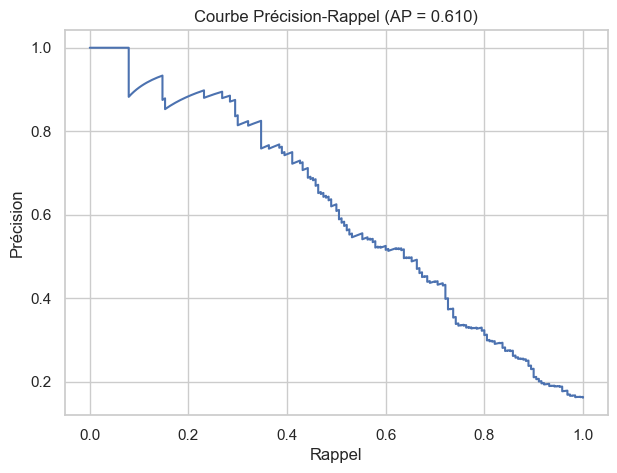

In [10]:
precision_arr, recall_arr, thresholds_arr = precision_recall_curve(y_train, oof_proba)
ap_score = average_precision_score(y_train, oof_proba)

plt.figure(figsize=(7, 5))
plt.plot(recall_arr, precision_arr)
plt.xlabel("Rappel")
plt.ylabel("Précision")
plt.title(f"Courbe Précision-Rappel (AP = {ap_score:.3f})")
plt.show()

In [11]:
# tableau des seuils avec precision, rappel et f1 pour chaque valeur
threshold_table = pd.DataFrame({
    "threshold": thresholds_arr,
    "precision": precision_arr[:-1],
    "recall": recall_arr[:-1]
})

threshold_table["f1"] = (
    2 * threshold_table["precision"] * threshold_table["recall"]
    / (threshold_table["precision"] + threshold_table["recall"]).replace(0, np.nan)
)

threshold_table.sort_values("f1", ascending=False).head(10)

,threshold,precision,recall,f1
942,0.545158,0.517094,0.636842,0.570755
945,0.550432,0.519481,0.631579,0.570071
941,0.544514,0.514894,0.636842,0.569412
944,0.549765,0.517241,0.631579,0.568720
940,0.543870,0.512712,0.636842,0.568075
947,0.552716,0.519651,0.626316,0.568019
943,0.547925,0.515021,0.631579,0.567376
939,0.543489,0.510549,0.636842,0.566745
946,0.550690,0.517391,0.626316,0.566667
949,0.554757,0.519824,0.621053,0.565947


### Seuil optimisé

On cherche le seuil qui maximise le F1-score sur les probabilités out-of-fold, soit le meilleur compromis entre précision et rappel.

In [12]:
best_row = threshold_table.sort_values("f1", ascending=False).iloc[0]
threshold_optimise = best_row["threshold"]

print(f"Seuil optimisé : {threshold_optimise:.3f}")
print(f"  Précision = {best_row['precision']:.3f}")
print(f"  Rappel    = {best_row['recall']:.3f}")
print(f"  F1        = {best_row['f1']:.3f}")

Seuil optimisé : 0.545
  Précision = 0.517
  Rappel    = 0.637
  F1        = 0.571


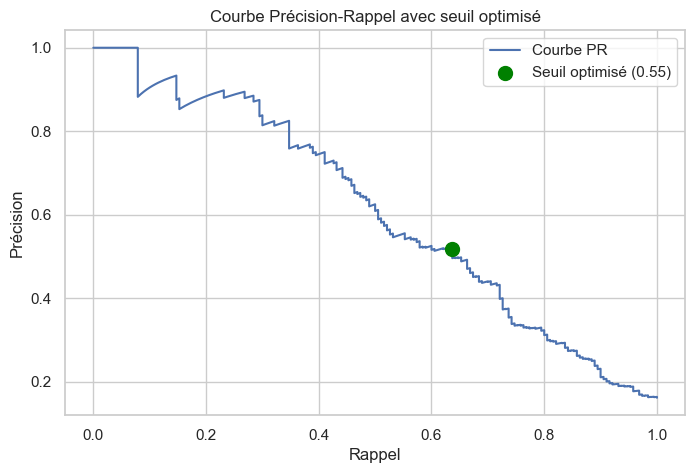

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(recall_arr, precision_arr, label="Courbe PR")

plt.scatter([best_row["recall"]], [best_row["precision"]],
            color="green", s=100, zorder=5, label=f"Seuil optimisé ({threshold_optimise:.2f})")

plt.xlabel("Rappel")
plt.ylabel("Précision")
plt.title("Courbe Précision-Rappel avec seuil optimisé")
plt.legend()
plt.show()

## Évaluation finale sur le jeu de test

On entraîne le modèle final sur l'ensemble du jeu d'entraînement, puis on évalue sur le jeu de test.  
Les métriques sont calculées sur le train et sur le test pour mesurer le surapprentissage.

In [14]:
final_model = XGBClassifier(
    n_estimators=100,
    max_depth=2,
    learning_rate=0.05,
    subsample=0.6,
    colsample_bytree=0.7,
    min_child_weight=20,
    reg_alpha=0.5,
    reg_lambda=3.0,
    gamma=0.3,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42
)

final_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

### Rapport de classification avec le seuil optimisé

In [15]:
train_proba = final_model.predict_proba(X_train)[:, 1]
test_proba = final_model.predict_proba(X_test)[:, 1]

y_train_pred = (train_proba >= threshold_optimise).astype(int)
y_test_pred = (test_proba >= threshold_optimise).astype(int)

print(f"Seuil optimisé : {threshold_optimise:.3f}")

print("\n--- Train ---")
print(classification_report(y_train, y_train_pred, zero_division=0))

print("--- Test ---")
print(classification_report(y_test, y_test_pred, zero_division=0))

Seuil optimisé : 0.545

--- Train ---
              precision    recall  f1-score   support

           0       0.95      0.89      0.92       986
           1       0.58      0.75      0.65       190

    accuracy                           0.87      1176
   macro avg       0.76      0.82      0.79      1176
weighted avg       0.89      0.87      0.88      1176

--- Test ---
              precision    recall  f1-score   support

           0       0.92      0.85      0.88       247
           1       0.44      0.62      0.51        47

    accuracy                           0.81       294
   macro avg       0.68      0.73      0.70       294
weighted avg       0.84      0.81      0.82       294



### Matrices de confusion

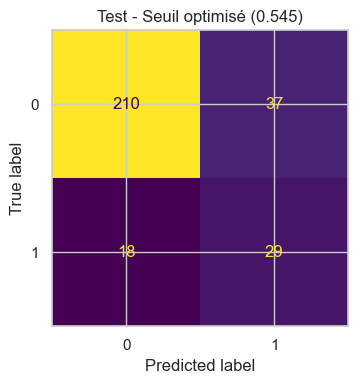

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, ax=ax, colorbar=False)
ax.set_title(f"Test - Seuil optimisé ({threshold_optimise:.3f})")

plt.tight_layout()
plt.show()

### Analyse du surapprentissage

In [17]:
print("Écart train / test (F1 sur classe 1) :")

train_f1 = f1_score(y_train, y_train_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
gap = train_f1 - test_f1

print(f"  Train F1 = {train_f1:.3f}")
print(f"  Test  F1 = {test_f1:.3f}")
print(f"  Écart    = {gap:.3f}")

Écart train / test (F1 sur classe 1) :
  Train F1 = 0.653
  Test  F1 = 0.513
  Écart    = 0.140


## Interprétation

Deux approches de gestion du déséquilibre ont été testées en validation croisée :
- `scale_pos_weight` pondère la classe minoritaire directement dans XGBoost
- SMOTE génère des exemples synthétiques, appliqué uniquement dans chaque fold d'entraînement

Le seuil de décision a été ajusté via la courbe précision-rappel pour maximiser le F1-score.  
Ce seuil offre le meilleur compromis entre précision et rappel.

On ne retient pas l'accuracy comme métrique principale car avec 84 % de classe majoritaire, un modèle qui prédit toujours 0 obtiendrait déjà 84 % d'accuracy.  
On privilégie la précision, le rappel et le F1 sur la classe 1.

La régularisation renforcée (profondeur max réduite à 2, subsampling à 0.6, pénalités L1/L2) contribue à limiter l'écart entre train et test par rapport au modèle du notebook 03.

Les scores restent modestes, ce qui s'explique par la taille du dataset (environ 237 positifs sur 1470 observations) et par la nature du problème : l'attrition dépend de nombreux facteurs, dont certains ne sont probablement pas capturés dans les données disponibles.  
Le modèle surpasse nettement le Dummy et détecte des patterns utiles, ce qui est suffisant pour l'objectif principal de la mission : identifier les facteurs les plus influents via SHAP.